# Phase 4 — Early Yield Prediction LSTM

Predicts **yield per acre** (`Annual_Yield / Area`) from partial in-season fortnight
sequences, then rescales to **total `Annual_Yield`** by multiplying by field `Area`.

**Why per acre:** `Annual_Yield` is ~95% driven by field `Area` (R2=0.95), which the
spectral features cannot see. Yield-per-acre is what the vegetation indices actually
explain (tight distribution, CV~0.25), so the LSTM learns a real signal. Total yield
is recovered afterward: `predicted_total = predicted_per_acre * Area`.

**Key training setup:**
- Target = **yield per acre**; metrics reported for **both per-acre and total**
- Scale **features and target** with `StandardScaler`
- **Train / val / test** split by `field_id` (val used for early stopping)
- **EarlyStopping** + **ReduceLROnPlateau** callbacks
- **Hyperparameter search** on Full_season checkpoint, then evaluate all cutoffs

**Input:** `usa_fortnight_yield_mapped.csv` (Phase 3)


In [18]:
# --- CONFIG ---
INPUT_CSV = 'usa_fortnight_yield_mapped.csv'
OUTPUT_RESULTS_CSV = 'phase4_checkpoint_results.csv'
OUTPUT_TUNING_CSV = 'phase4_tuning_results.csv'
OUTPUT_PARAMS_JSON = 'phase4_best_params.json'
OUTPUT_MODEL_PATH = 'usa_yield_lstm.keras'

CSV_SEARCH_PATHS = [
    'usa_fortnight_yield_mapped.csv',
    '../data/usa_fortnight_yield_mapped.csv',
    'data/usa_fortnight_yield_mapped.csv',
    '/content/usa_fortnight_yield_mapped.csv',
]

TEST_SIZE = 0.20       # held-out field_ids
VAL_SIZE = 0.15        # validation field_ids (from train pool)
EPOCHS = 1000
TUNE_EPOCHS = 80
MAX_TUNING_COMBOS = 24 # cap grid search for Colab runtime
RANDOM_STATE = 42

FEATURE_COLS = [
    'NDVI', 'EVI', 'GNDVI', 'SAVI', 'MSAVI',
    'MOISTURE', 'LAI', 'NDMI_8', 'NDWI_8', 'Elevation',
]

CHECKPOINTS = {
    'Early': '06-15',
    'Mid': '07-15',
    'Late': '08-15',
    'Pre_harvest': '09-15',
    'Full_season': None,
}

# Hyperparameter search space (tuned on Full_season)
PARAM_GRID = {
    'look_back': [3, 4, 5],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'lstm_units': [(32, 32), (50, 32)],
    'dropout': [0.2, 0.3],
    'batch_size': [64, 128],
}

In [19]:
import glob
import json
import os
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

sns.set_theme(style='whitegrid')
%matplotlib inline

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def resolve_input_csv():
    if os.path.exists(INPUT_CSV):
        return INPUT_CSV
    for path in CSV_SEARCH_PATHS:
        if os.path.exists(path):
            return path
    if IN_COLAB:
        drive_matches = sorted(glob.glob('/content/drive/MyDrive/**/usa_fortnight_yield_mapped.csv', recursive=True))
        if drive_matches:
            return drive_matches[0]
    if IN_COLAB:
        print(f'{INPUT_CSV} not found — upload Phase 3 output:')
        uploaded = files.upload()
        return next(iter(uploaded))
    raise FileNotFoundError('Run Phase 3 first or place usa_fortnight_yield_mapped.csv in working directory')


csv_path = resolve_input_csv()
df = pd.read_csv(csv_path)
df['fortnight_start'] = pd.to_datetime(df['fortnight_start'])
if 'Area' not in df.columns and 'area' in df.columns:
    df['Area'] = df['area']
df = df.dropna(subset=['season_fortnight_index', 'Annual_Yield', 'Area'])
df = df[df['Area'] > 0]
df = df.dropna(subset=FEATURE_COLS, how='any')

# LSTM target: yield per acre (what spectral features actually explain).
# Total yield is recovered later as per_acre * Area.
df['yield_per_acre'] = df['Annual_Yield'] / df['Area']

print('Loaded:', csv_path)
print('Rows:', len(df), '| Fields:', df['field_id'].nunique(), '| field-years:', df.groupby(['field_id','year']).ngroups)
print('Annual_Yield  range:', round(df['Annual_Yield'].min(), 2), '->', round(df['Annual_Yield'].max(), 2))
print('yield_per_acre range:', round(df['yield_per_acre'].min(), 2), '->', round(df['yield_per_acre'].max(), 2))

Loaded: usa_fortnight_yield_mapped.csv
Rows: 14490 | Fields: 699 | field-years: 2097
Annual_Yield  range: 1.08 -> 2353.41
yield_per_acre range: 4.86 -> 52.39


## Sequence builder + scaled training helpers


In [20]:
def build_field_sequences(frame, look_back, cutoff_md=None):
    # Target is yield PER ACRE; areas are returned so predictions can be
    # rescaled to total tons (predicted_total = per_acre * Area).
    X_list, y_list, area_list, meta = [], [], [], []
    for (field_id, year), grp in frame.groupby(['field_id', 'year']):
        grp = grp.sort_values('season_fortnight_index')
        if cutoff_md is not None:
            cutoff = pd.Timestamp(f"{int(year)}-{cutoff_md}")
            grp = grp[grp['fortnight_start'] <= cutoff]
        if len(grp) <= look_back:
            continue
        feats = grp[FEATURE_COLS].values
        target = grp['yield_per_acre'].iloc[-1]
        area = grp['Area'].iloc[-1]
        for i in range(look_back, len(feats)):
            X_list.append(feats[i - look_back:i])
            y_list.append(target)
            area_list.append(area)
            meta.append((int(field_id), int(year)))
    if not X_list:
        return (np.empty((0, look_back, len(FEATURE_COLS))), np.empty((0,)),
                np.empty((0,)), [])
    return np.asarray(X_list), np.asarray(y_list), np.asarray(area_list), meta


def split_train_val_test(meta, test_size, val_size, random_state):
    fields = sorted({m[0] for m in meta})
    train_fields, test_fields = train_test_split(fields, test_size=test_size, random_state=random_state)
    train_fields, val_fields = train_test_split(train_fields, test_size=val_size, random_state=random_state)
    train_set, val_set, test_set = set(train_fields), set(val_fields), set(test_fields)
    train_idx = [i for i, m in enumerate(meta) if m[0] in train_set]
    val_idx = [i for i, m in enumerate(meta) if m[0] in val_set]
    test_idx = [i for i, m in enumerate(meta) if m[0] in test_set]
    return train_idx, val_idx, test_idx


def scale_splits(X_train, y_train, X_val, y_val, X_test):
    n_feat = X_train.shape[2]
    x_scaler = StandardScaler()
    x_scaler.fit(X_train.reshape(-1, n_feat))

    def transform_x(X):
        return x_scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape)

    y_scaler = StandardScaler()
    y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
    return transform_x(X_train), y_train_s, transform_x(X_val), y_val_s, transform_x(X_test), x_scaler, y_scaler


def make_lstm(input_shape, lstm_units=(32, 32), dropout=0.2, learning_rate=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(lstm_units[0], return_sequences=True),
        Dropout(dropout),
        LSTM(lstm_units[1]),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout / 2),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model


def fit_model(model, X_train, y_train, X_val, y_val, epochs, batch_size, verbose=1):
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ]
    return model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        callbacks=callbacks,
        verbose=verbose,
    )


def predict_yield(model, X, y_scaler):
    pred_s = model.predict(X, verbose=0).ravel()
    return y_scaler.inverse_transform(pred_s.reshape(-1, 1)).ravel()


def evaluate_params(frame, params, cutoff_md, epochs, verbose=0):
    look_back = params['look_back']
    X, y, areas, meta = build_field_sequences(frame, look_back, cutoff_md)
    train_idx, val_idx, test_idx = split_train_val_test(meta, TEST_SIZE, VAL_SIZE, RANDOM_STATE)
    if not train_idx or not val_idx or not test_idx:
        return None

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    area_val, area_test = areas[val_idx], areas[test_idx]

    X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, _, y_scaler = scale_splits(
        X_train, y_train, X_val, y_val, X_test
    )

    model = make_lstm(
        (look_back, X_train.shape[2]),
        lstm_units=params['lstm_units'],
        dropout=params['dropout'],
        learning_rate=params['learning_rate'],
    )
    history = fit_model(model, X_train_s, y_train_s, X_val_s, y_val_s, epochs, params['batch_size'], verbose=verbose)

    # Per-acre predictions (model output space)
    val_pred = predict_yield(model, X_val_s, y_scaler)
    test_pred = predict_yield(model, X_test_s, y_scaler)

    # Rescale to total tons for reporting
    val_total_true, val_total_pred = y_val * area_val, val_pred * area_val
    test_total_true, test_total_pred = y_test * area_test, test_pred * area_test

    return {
        'model': model,
        'history': history,
        'y_scaler': y_scaler,
        # per-acre metrics (what the model directly optimizes)
        'val_rmse': float(np.sqrt(mean_squared_error(y_val, val_pred))),
        'test_rmse': float(np.sqrt(mean_squared_error(y_test, test_pred))),
        'test_mae': float(mean_absolute_error(y_test, test_pred)),
        # total-yield metrics (per_acre * Area)
        'test_rmse_total': float(np.sqrt(mean_squared_error(test_total_true, test_total_pred))),
        'test_mae_total': float(mean_absolute_error(test_total_true, test_total_pred)),
        # arrays for plotting
        'y_test': y_test,
        'test_pred': test_pred,
        'area_test': area_test,
        'test_total_true': test_total_true,
        'test_total_pred': test_total_pred,
        'n_samples': len(X),
    }

## Hyperparameter tuning (Full_season checkpoint)

Searches `PARAM_GRID` and picks the combo with lowest **validation RMSE**.


In [21]:
keys = list(PARAM_GRID.keys())
combos = [dict(zip(keys, vals)) for vals in product(*PARAM_GRID.values())]
combos = combos[:MAX_TUNING_COMBOS]

tuning_rows = []
best_params = None
best_val = np.inf

for i, params in enumerate(combos, start=1):
    stats = evaluate_params(df, params, CHECKPOINTS['Full_season'], epochs=TUNE_EPOCHS, verbose=0)
    if stats is None:
        continue
    row = {**params, 'lstm_units': str(params['lstm_units']), 'val_rmse': stats['val_rmse'], 'test_rmse': stats['test_rmse']}
    tuning_rows.append(row)
    print(f"[{i}/{len(combos)}] lb={params['look_back']} lr={params['learning_rate']} units={params['lstm_units']} "
          f"drop={params['dropout']} batch={params['batch_size']} -> val_rmse(per-acre)={stats['val_rmse']:.3f}")
    if stats['val_rmse'] < best_val:
        best_val = stats['val_rmse']
        best_params = params.copy()

# restore tuple for lstm_units after serialization in dataframe
best_params['lstm_units'] = tuple(best_params['lstm_units']) if isinstance(best_params['lstm_units'], list) else best_params['lstm_units']

tuning_df = pd.DataFrame(tuning_rows).sort_values('val_rmse')
print('\nBest params:')
print(best_params)
tuning_df.head(10)

Restoring model weights from the end of the best epoch: 80.
[1/24] lb=3 lr=0.0001 units=(32, 32) drop=0.2 batch=64 -> val_rmse(per-acre)=4.395
Restoring model weights from the end of the best epoch: 79.
[2/24] lb=3 lr=0.0001 units=(32, 32) drop=0.2 batch=128 -> val_rmse(per-acre)=4.514

Epoch 78: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Restoring model weights from the end of the best epoch: 73.
[3/24] lb=3 lr=0.0001 units=(32, 32) drop=0.3 batch=64 -> val_rmse(per-acre)=4.483
Restoring model weights from the end of the best epoch: 80.
[4/24] lb=3 lr=0.0001 units=(32, 32) drop=0.3 batch=128 -> val_rmse(per-acre)=4.573
Restoring model weights from the end of the best epoch: 80.
[5/24] lb=3 lr=0.0001 units=(50, 32) drop=0.2 batch=64 -> val_rmse(per-acre)=4.391
Restoring model weights from the end of the best epoch: 77.
[6/24] lb=3 lr=0.0001 units=(50, 32) drop=0.2 batch=128 -> val_rmse(per-acre)=4.481
Restoring model weights from the end of the best epoch: 80.
[

,look_back,learning_rate,lstm_units,dropout,batch_size,val_rmse,test_rmse
17,3,0.0010,"(32, 32)",0.2,128,3.974854,4.282688
18,3,0.0010,"(32, 32)",0.3,64,3.994808,4.172964
22,3,0.0010,"(50, 32)",0.3,64,4.052145,4.265419
19,3,0.0010,"(32, 32)",0.3,128,4.056392,4.321448
21,3,0.0010,"(50, 32)",0.2,128,4.065743,4.301116
16,3,0.0010,"(32, 32)",0.2,64,4.065852,4.308992
23,3,0.0010,"(50, 32)",0.3,128,4.076576,4.281239
14,3,0.0005,"(50, 32)",0.3,64,4.083673,4.268765
20,3,0.0010,"(50, 32)",0.2,64,4.099392,4.317153
12,3,0.0005,"(50, 32)",0.2,64,4.108282,4.328345


## Evaluate all early-prediction checkpoints with best params


In [22]:
results = []
pred_store = {}
last_history = None

for name, cutoff in CHECKPOINTS.items():
    stats = evaluate_params(df, best_params, cutoff, epochs=EPOCHS, verbose=0)
    if stats is None:
        results.append({'checkpoint': name, 'cutoff': cutoff or 'all', 'rmse': np.nan, 'mae': np.nan})
        continue
    results.append({
        'checkpoint': name,
        'cutoff': cutoff or 'all',
        'rmse_per_acre': stats['test_rmse'],
        'mae_per_acre': stats['test_mae'],
        'rmse_total': stats['test_rmse_total'],
        'mae_total': stats['test_mae_total'],
        'val_rmse_per_acre': stats['val_rmse'],
        'n_samples': stats['n_samples'],
        **best_params,
    })
    pred_store[name] = {
        'per_acre': (stats['y_test'], stats['test_pred']),
        'total': (stats['test_total_true'], stats['test_total_pred']),
    }
    last_history = stats['history']
    print(f"{name:14s} per-acre RMSE={stats['test_rmse']:6.2f} MAE={stats['test_mae']:6.2f} | "
          f"total RMSE={stats['test_rmse_total']:8.2f} MAE={stats['test_mae_total']:8.2f}")

results_df = pd.DataFrame(results)
results_df


Epoch 67: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 72: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 87: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 92: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 97: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 102: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 107: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
Epoch 110: early stopping
Restoring model weights from the end of the best epoch: 95.
Early          per-acre RMSE=  3.95 MAE=  3.05 | total RMSE=   27.76 MAE=   10.23

Epoch 56: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 67: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 79: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 84: ReduceLROnPlateau reducing learning rat

,checkpoint,cutoff,rmse_per_acre,mae_per_acre,rmse_total,mae_total,val_rmse_per_acre,n_samples,look_back,learning_rate,lstm_units,dropout,batch_size
0,Early,06-15,3.945748,3.048423,27.762130,10.225149,3.362992,1744,3,0.001,"(32, 32)",0.2,128
1,Mid,07-15,3.885329,3.033972,18.742730,7.481328,3.799858,3323,3,0.001,"(32, 32)",0.2,128
2,Late,08-15,4.166799,3.209398,26.816658,10.603447,3.940541,5752,3,0.001,"(32, 32)",0.2,128
3,Pre_harvest,09-15,4.306541,3.322915,27.358397,10.776232,4.151050,8247,3,0.001,"(32, 32)",0.2,128
4,Full_season,all,4.305116,3.301730,27.422710,10.674869,4.090473,8247,3,0.001,"(32, 32)",0.2,128


In [23]:
# Save outputs
with open(OUTPUT_PARAMS_JSON, 'w') as f:
    json.dump({**best_params, 'lstm_units': list(best_params['lstm_units'])}, f, indent=2)
results_df.to_csv(OUTPUT_RESULTS_CSV, index=False)
tuning_df.to_csv(OUTPUT_TUNING_CSV, index=False)

# Save final full-season model
full_stats = evaluate_params(df, best_params, None, epochs=EPOCHS, verbose=1)
full_stats['model'].save(OUTPUT_MODEL_PATH)

print('Saved:', OUTPUT_RESULTS_CSV, OUTPUT_TUNING_CSV, OUTPUT_PARAMS_JSON, OUTPUT_MODEL_PATH)
if IN_COLAB:
    for p in [OUTPUT_RESULTS_CSV, OUTPUT_TUNING_CSV, OUTPUT_PARAMS_JSON, OUTPUT_MODEL_PATH]:
        files.download(p)

Epoch 1/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8916 - mae: 0.7744 - val_loss: 0.6207 - val_mae: 0.6409 - learning_rate: 0.0010
Epoch 2/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6726 - mae: 0.6747 - val_loss: 0.5734 - val_mae: 0.6125 - learning_rate: 0.0010
Epoch 3/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6374 - mae: 0.6457 - val_loss: 0.5305 - val_mae: 0.5892 - learning_rate: 0.0010
Epoch 4/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5879 - mae: 0.6191 - val_loss: 0.4819 - val_mae: 0.5588 - learning_rate: 0.0010
Epoch 5/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5687 - mae: 0.6092 - val_loss: 0.4776 - val_mae: 0.5543 - learning_rate: 0.0010
Epoch 6/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5384 - mae: 0.5898 - val_loss: 0.4722 - val_mae: 0.5513 - learning_rate: 0.0010
Epoch 7/1000
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5409 - mae: 0.5911 - val_loss: 0.4779 - val_mae: 0.5527 - learning_rate: 0.0010
Epoch 

## Training curve (scaled loss should decrease smoothly)


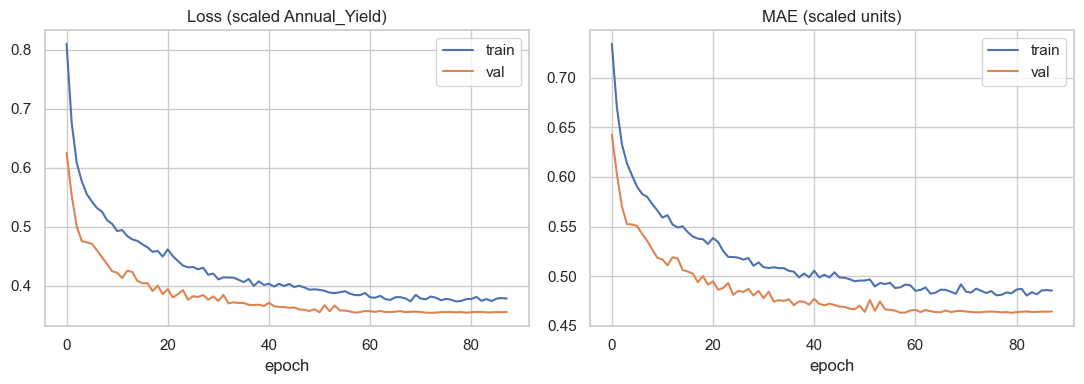

In [24]:
if last_history is not None:
    h = last_history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h['loss'], label='train')
    ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title('Loss (scaled Annual_Yield)')
    ax[0].set_xlabel('epoch')
    ax[0].legend()
    ax[1].plot(h['mae'], label='train')
    if 'val_mae' in h:
        ax[1].plot(h['val_mae'], label='val')
    ax[1].set_title('MAE (scaled units)')
    ax[1].set_xlabel('epoch')
    ax[1].legend()
    plt.tight_layout()
    plt.show()

## Checkpoint RMSE / MAE plots


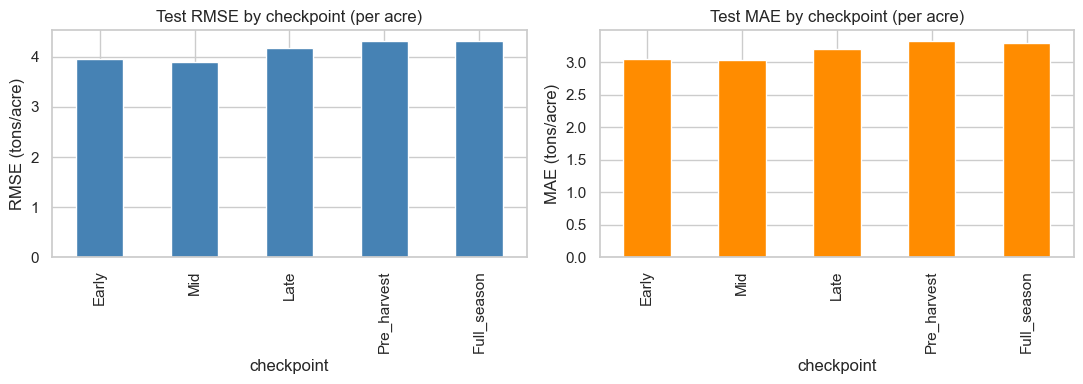

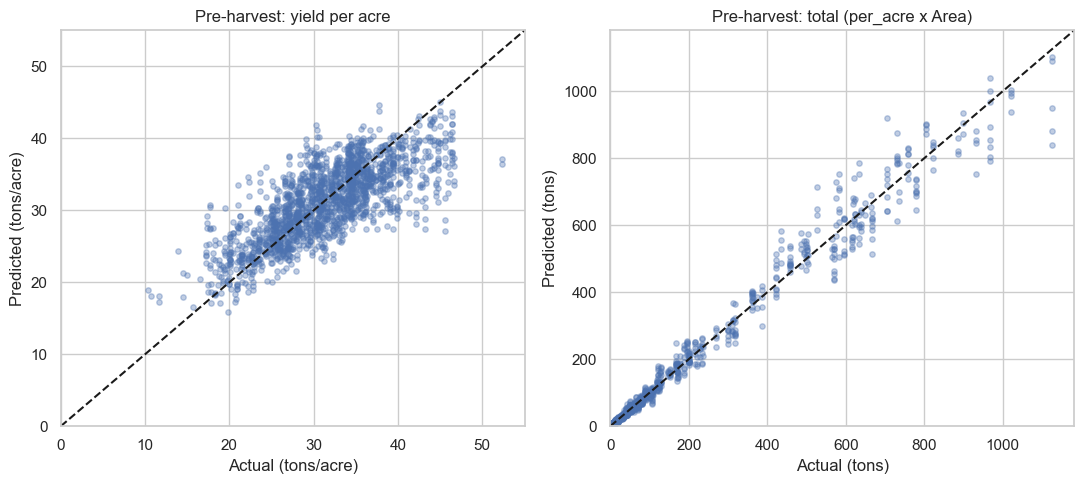

In [25]:
order = list(CHECKPOINTS.keys())
plot_df = results_df.set_index('checkpoint').loc[order]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_df['rmse_per_acre'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Test RMSE by checkpoint (per acre)')
ax[0].set_ylabel('RMSE (tons/acre)')
plot_df['mae_per_acre'].plot(kind='bar', ax=ax[1], color='darkorange')
ax[1].set_title('Test MAE by checkpoint (per acre)')
ax[1].set_ylabel('MAE (tons/acre)')
plt.tight_layout()
plt.show()


def scatter_pred(ax, y_true, y_pred, title, unit):
    ax.scatter(y_true, y_pred, alpha=0.35, s=15)
    lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lim, lim, 'k--')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'Actual ({unit})')
    ax.set_ylabel(f'Predicted ({unit})')
    ax.set_title(title)


if 'Pre_harvest' in pred_store:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ypa_true, ypa_pred = pred_store['Pre_harvest']['per_acre']
    tot_true, tot_pred = pred_store['Pre_harvest']['total']
    scatter_pred(ax[0], ypa_true, ypa_pred, 'Pre-harvest: yield per acre', 'tons/acre')
    scatter_pred(ax[1], tot_true, tot_pred, 'Pre-harvest: total (per_acre x Area)', 'tons')
    plt.tight_layout()
    plt.show()